Using device: cuda

=== Building Datasets ===
Total pairs: 2103
Computing Laplacian variance for stratification…


  Laplacian: 100%|██████████| 2103/2103 [01:20<00:00, 26.25it/s]


  Low: 701 total → 560 train / 141 val
  Mid: 701 total → 560 train / 141 val
  High: 701 total → 560 train / 141 val

Loading NAFNet...


  Deblurring val: 100%|██████████| 423/423 [00:00<00:00, 28947.47it/s]


  Deblurred 1680 train + 423 val images.

Generating pseudo-labels (single YOLO pass)…


  Pseudo val: 100%|██████████| 423/423 [00:14<00:00, 28.99it/s]


  Pseudo: 1184/1680 train | 313/423 val labelled

Building YOLO dataset folder…
  Dataset folder ready.

=== Training pseudo ===
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/outputs/task4/datasets/pseudo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.

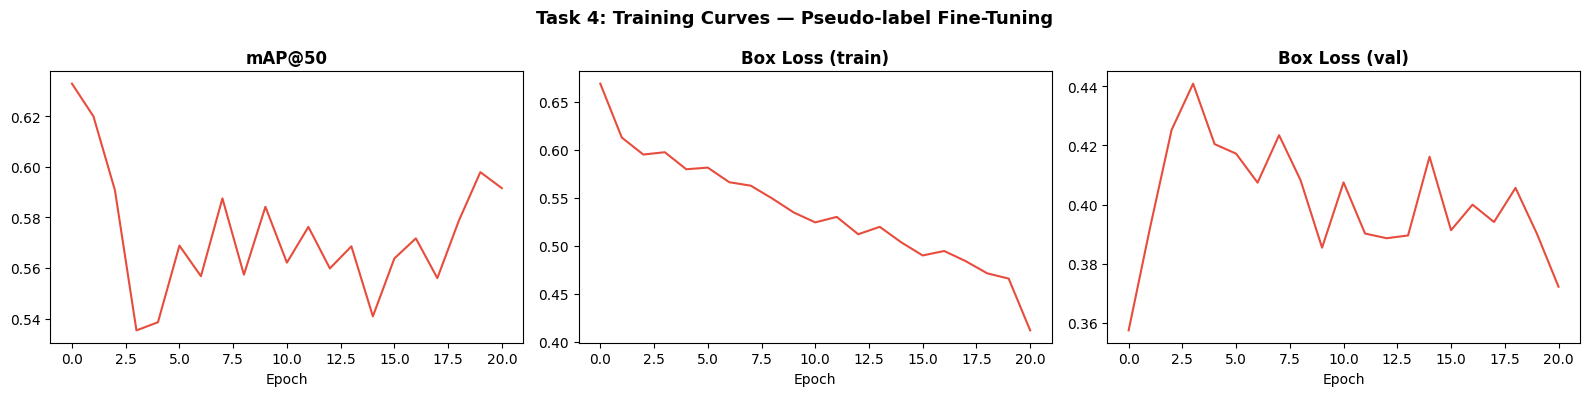

Saved: task4_training_curves.png

Generating visual comparison on reference images…


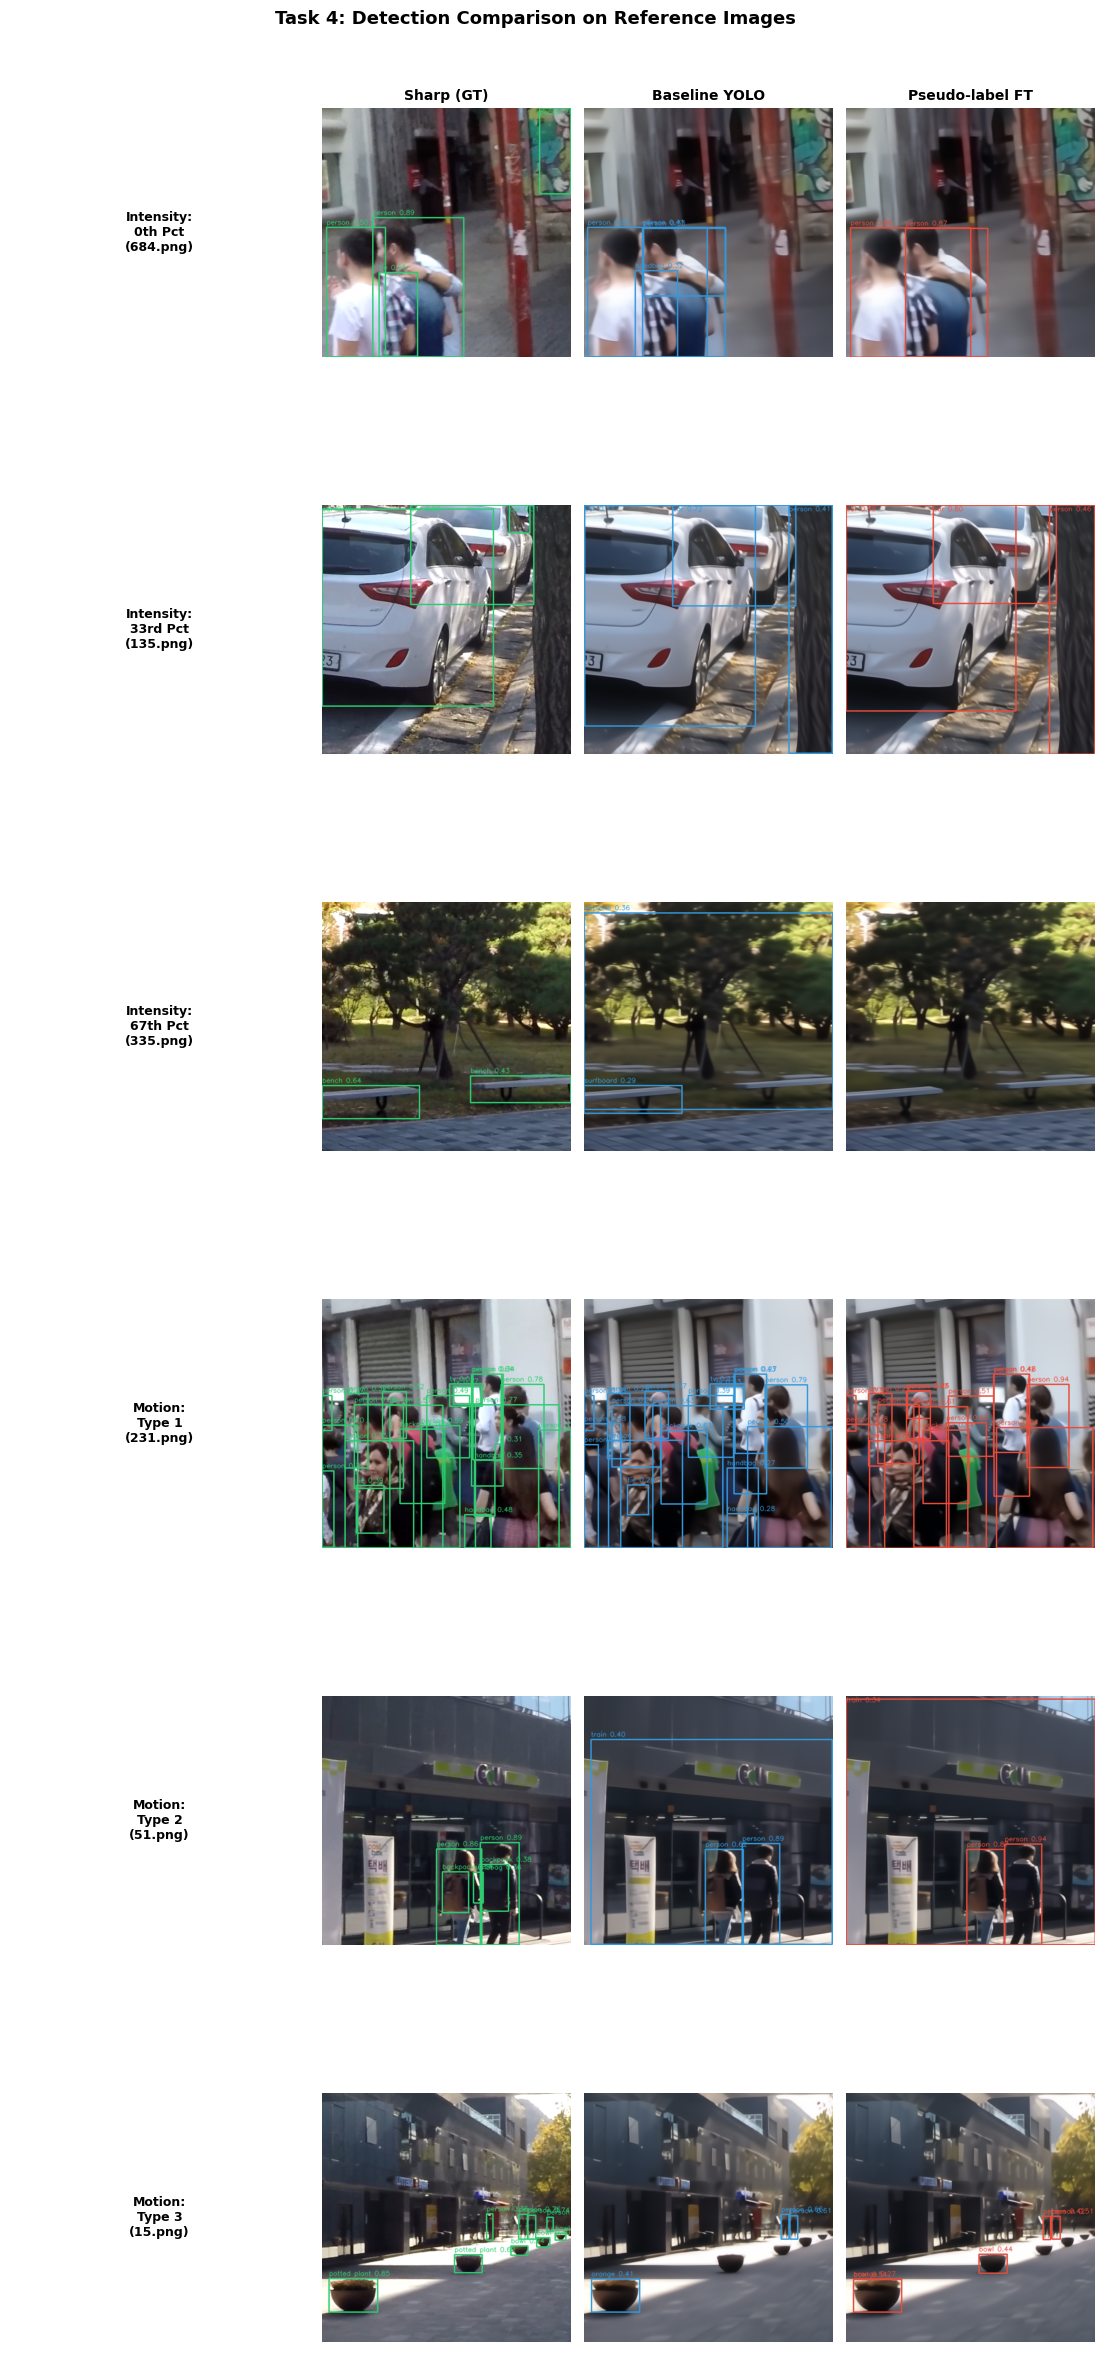

Saved: task4_visual_comparison.png

=== Task 4 Complete. Outputs saved to: /kaggle/working/outputs/task4 ===


In [3]:
# ============================================================
# Task 4: Dataset Preparation and Fine-Tuning
# Strategy: Pseudo-label — train on deblurred images, labels from YOLOv8m(deblurred)
# ============================================================

import gc, shutil, warnings, subprocess
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from tqdm import tqdm

subprocess.run(["pip", "install", "ultralytics", "gdown", "-q"], check=True)
from ultralytics import YOLO

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.cuda.empty_cache(); gc.collect()

# ── 1. Paths ─────────────────────────────────────────────────────────────────
TRAIN_BLUR  = Path("/kaggle/input/datasets/jishnuparayilshibu/a-curated-list-of-image-deblurring-datasets/DBlur/Gopro/train/blur")
TRAIN_SHARP = Path("/kaggle/input/datasets/jishnuparayilshibu/a-curated-list-of-image-deblurring-datasets/DBlur/Gopro/train/sharp")
TEST_BLUR   = Path("/kaggle/input/datasets/jishnuparayilshibu/a-curated-list-of-image-deblurring-datasets/DBlur/Gopro/test/blur")
TEST_SHARP  = Path("/kaggle/input/datasets/jishnuparayilshibu/a-curated-list-of-image-deblurring-datasets/DBlur/Gopro/test/sharp")
NAFNET_WEIGHTS = Path("./weights/NAFNet-GoPro-width64.pth")

OUTPUT_DIR = Path("/kaggle/working/outputs/task4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DS_A = OUTPUT_DIR / "datasets" / "pseudo"

IMG_EXTS    = {".png", ".jpg", ".jpeg", ".bmp"}
TRAIN_RATIO = 0.80
MAX_SAMPLES = None
CROP_SIZE   = 512

REF_IMAGES = ["684.png", "135.png", "335.png", "231.png", "51.png", "15.png"]
REF_LABELS_MAP = {
    "684.png": "Intensity:\n0th Pct",
    "135.png": "Intensity:\n33rd Pct",
    "335.png": "Intensity:\n67th Pct",
    "231.png": "Motion:\nType 1",
    "51.png":  "Motion:\nType 2",
    "15.png":  "Motion:\nType 3",
}

# ── 2. NAFNet definition ──────────────────────────────────────────────────────
import torch.nn as nn
import torch.nn.functional as F

class LayerNormFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, weight, bias, eps):
        ctx.eps = eps
        N, C, H, W = x.size()
        mu = x.mean(1, keepdim=True)
        var = (x - mu).pow(2).mean(1, keepdim=True)
        y = (x - mu) / (var + eps).sqrt()
        ctx.save_for_backward(y, var, weight)
        return weight.view(1, C, 1, 1) * y + bias.view(1, C, 1, 1)
    @staticmethod
    def backward(ctx, grad_output):
        eps = ctx.eps
        N, C, H, W = grad_output.size()
        y, var, weight = ctx.saved_tensors
        g = grad_output * weight.view(1, C, 1, 1)
        mean_g = g.mean(dim=1, keepdim=True)
        mean_gy = (g * y).mean(dim=1, keepdim=True)
        gx = 1. / torch.sqrt(var + eps) * (g - y * mean_gy - mean_g)
        return gx, (grad_output * y).sum(dim=[0,2,3]), grad_output.sum(dim=[0,2,3]), None

class LayerNorm2d(nn.Module):
    def __init__(self, channels, eps=1e-6):
        super().__init__()
        self.register_parameter("weight", nn.Parameter(torch.ones(channels)))
        self.register_parameter("bias",   nn.Parameter(torch.zeros(channels)))
        self.eps = eps
    def forward(self, x):
        return LayerNormFunction.apply(x, self.weight, self.bias, self.eps)

class SimpleGate(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2

class NAFBlock(nn.Module):
    def __init__(self, c, DW_Expand=2, FFN_Expand=2, drop_out_rate=0.):
        super().__init__()
        dw_channel = c * DW_Expand
        self.conv1 = nn.Conv2d(c, dw_channel, 1, bias=True)
        self.conv2 = nn.Conv2d(dw_channel, dw_channel, 3, padding=1, groups=dw_channel, bias=True)
        self.conv3 = nn.Conv2d(dw_channel // 2, c, 1, bias=True)
        self.sca = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(dw_channel // 2, dw_channel // 2, 1, bias=True))
        self.sg = SimpleGate()
        ffn_channel = FFN_Expand * c
        self.conv4 = nn.Conv2d(c, ffn_channel, 1, bias=True)
        self.conv5 = nn.Conv2d(ffn_channel // 2, c, 1, bias=True)
        self.norm1 = LayerNorm2d(c)
        self.norm2 = LayerNorm2d(c)
        self.beta  = nn.Parameter(torch.zeros((1, c, 1, 1)), requires_grad=True)
        self.gamma = nn.Parameter(torch.zeros((1, c, 1, 1)), requires_grad=True)
        self.dropout1 = nn.Dropout(drop_out_rate) if drop_out_rate > 0 else nn.Identity()
        self.dropout2 = nn.Dropout(drop_out_rate) if drop_out_rate > 0 else nn.Identity()
    def forward(self, inp):
        x = self.norm1(inp)
        x = self.conv1(x); x = self.conv2(x); x = self.sg(x)
        x = x * self.sca(x); x = self.conv3(x)
        x = self.dropout1(x)
        y = inp + x * self.beta
        x = self.conv4(self.norm2(y)); x = self.sg(x); x = self.conv5(x)
        return y + self.dropout2(x) * self.gamma

class NAFNet(nn.Module):
    def __init__(self, img_channel=3, width=16, middle_blk_num=1, enc_blks=[], dec_blks=[]):
        super().__init__()
        self.intro    = nn.Conv2d(img_channel, width, 3, padding=1)
        self.ending   = nn.Conv2d(width, img_channel, 3, padding=1)
        self.encoders = nn.ModuleList()
        self.decoders = nn.ModuleList()
        self.middle_blks = nn.Sequential(*[NAFBlock(width * (2 ** len(enc_blks))) for _ in range(middle_blk_num)])
        self.ups   = nn.ModuleList()
        self.downs = nn.ModuleList()
        chan = width
        for num in enc_blks:
            self.encoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(num)]))
            self.downs.append(nn.Conv2d(chan, 2*chan, 2, 2))
            chan *= 2
        for num in dec_blks:
            self.ups.append(nn.Sequential(nn.Conv2d(chan, chan*2, 1), nn.PixelShuffle(2)))
            chan //= 2
            self.decoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(num)]))
        self.padder_size = 2 ** len(self.encoders)
    def check_image_size(self, x):
        _, _, h, w = x.size()
        ph = (self.padder_size - h % self.padder_size) % self.padder_size
        pw = (self.padder_size - w % self.padder_size) % self.padder_size
        return F.pad(x, (0, pw, 0, ph))
    def forward(self, inp):
        inp = self.check_image_size(inp)
        _, _, H, W = inp.shape
        x = self.intro(inp)
        encs = []
        for enc, down in zip(self.encoders, self.downs):
            x = enc(x); encs.append(x); x = down(x)
        x = self.middle_blks(x)
        for dec, up, skip in zip(self.decoders, self.ups, reversed(encs)):
            x = dec(up(x) + skip)
        return (self.ending(x) + inp)[:, :, :H, :W]

def load_nafnet():
    path = NAFNET_WEIGHTS
    path.parent.mkdir(exist_ok=True)
    if not path.exists():
        import gdown
        gdown.download(id="14D4V4raNYIOhETfcuuLI3bGLB-OYIv6X", output=str(path), quiet=False)
    ckpt = torch.load(path, map_location=device)
    state = ckpt.get("params_ema") or ckpt.get("params") or ckpt
    width = state["intro.weight"].shape[0]
    num_stages = len({k.split(".")[1] for k in state if k.startswith("downs.")})
    def nblocks(prefix):
        idxs = {int(k[len(prefix):].split(".")[0]) for k in state if k.startswith(prefix) and k[len(prefix):].split(".")[0].isdigit()}
        return max(idxs) + 1 if idxs else 0
    enc_blks = [nblocks(f"encoders.{i}.") for i in range(num_stages)]
    dec_blks  = [nblocks(f"decoders.{i}.") for i in range(num_stages)]
    mid_num   = nblocks("middle_blks.")
    model = NAFNet(width=width, middle_blk_num=mid_num, enc_blks=enc_blks, dec_blks=dec_blks)
    model.load_state_dict(state, strict=False)
    return model.to(device).eval()

def deblur_pil(model, pil_img):
    t = transforms.ToTensor()(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(t).clamp(0,1).squeeze().cpu()
    return transforms.ToPILImage()(out)

# ── 3. Build train/val splits (stratified by blur level) ─────────────────────
print("\n=== Building Datasets ===")

sharp_lookup_tr = {p.name: p for p in TRAIN_SHARP.rglob("*") if p.suffix.lower() in IMG_EXTS}
pairs = [(bp, sharp_lookup_tr[bp.name])
         for bp in sorted(TRAIN_BLUR.rglob("*"))
         if bp.suffix.lower() in IMG_EXTS and bp.name in sharp_lookup_tr]
if MAX_SAMPLES:
    pairs = pairs[:MAX_SAMPLES]
print(f"Total pairs: {len(pairs)}")

print("Computing Laplacian variance for stratification…")
scored = []
for bp, sp in tqdm(pairs, desc="  Laplacian"):
    img = cv2.imread(str(bp))
    if img is not None:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        scored.append((cv2.Laplacian(gray, cv2.CV_64F).var(), bp, sp))
scored.sort(key=lambda x: x[0])
n = len(scored)
t1, t2 = n // 3, 2 * n // 3
bins = [("Low", scored[:t1]), ("Mid", scored[t1:t2]), ("High", scored[t2:])]
train_pairs, val_pairs = [], []
for label, grp in bins:
    k = int(len(grp) * TRAIN_RATIO)
    train_pairs.extend([(bp, sp) for _, bp, sp in grp[:k]])
    val_pairs.extend(  [(bp, sp) for _, bp, sp in grp[k:]])
    print(f"  {label}: {len(grp)} total → {k} train / {len(grp)-k} val")

# ── 4. Deblur train+val images with NAFNet ───────────────────────────────────
print("\nLoading NAFNet...")
nafnet = load_nafnet()

DEBLUR_TRAIN = OUTPUT_DIR / "deblurred_train"; DEBLUR_TRAIN.mkdir(exist_ok=True)
DEBLUR_VAL   = OUTPUT_DIR / "deblurred_val";   DEBLUR_VAL.mkdir(exist_ok=True)
SHARP_TRAIN  = OUTPUT_DIR / "sharp_train";     SHARP_TRAIN.mkdir(exist_ok=True)

def process_split(split_pairs, deblur_dir, sharp_dir, desc):
    paths = []
    for bp, sp in tqdm(split_pairs, desc=f"  Deblurring {desc}"):
        fname = bp.name
        dp_out = deblur_dir / fname
        sp_out = sharp_dir  / fname
        if not sp_out.exists():
            TF.center_crop(Image.open(sp).convert("RGB"), (CROP_SIZE, CROP_SIZE)).save(sp_out)
        if not dp_out.exists():
            blur_pil = TF.center_crop(Image.open(bp).convert("RGB"), (CROP_SIZE, CROP_SIZE))
            deblur_pil(nafnet, blur_pil).save(dp_out)
        paths.append((fname, dp_out, sp_out))
    return paths

train_info = process_split(train_pairs, DEBLUR_TRAIN, SHARP_TRAIN, "train")
val_info   = process_split(val_pairs,   DEBLUR_VAL,   DEBLUR_VAL,  "val")

nafnet.cpu(); torch.cuda.empty_cache(); gc.collect()
print(f"  Deblurred {len(train_info)} train + {len(val_info)} val images.")

# ── 5. Generate pseudo-labels (single pass) ───────────────────────────────────
print("\nGenerating pseudo-labels (single YOLO pass)…")
detector = YOLO("yolov8m.pt")

CONF_THRESH = 0.40

def annotate(model, img_paths, label_dir, desc=""):
    label_dir.mkdir(parents=True, exist_ok=True)
    labelled = 0
    for fname, dp, sp in tqdm(img_paths, desc=f"  {desc}"):
        if not dp.exists():
            continue
        res  = model.predict(str(dp), conf=CONF_THRESH, verbose=False)[0]
        W, H = Image.open(dp).size
        lines = []
        for box, cls_id in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.cls.cpu().numpy()):
            cx = ((box[0]+box[2])/2)/W; cy = ((box[1]+box[3])/2)/H
            w  = (box[2]-box[0])/W;     h  = (box[3]-box[1])/H
            lines.append(f"{int(cls_id)} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
        txt = label_dir / f"{Path(fname).stem}.txt"
        txt.write_text("\n".join(lines))
        if lines:
            labelled += 1
    return labelled

lA_train = annotate(detector, train_info, DS_A/"labels"/"train", desc="Pseudo train")
lA_val   = annotate(detector, val_info,   DS_A/"labels"/"val",   desc="Pseudo val")
print(f"  Pseudo: {lA_train}/{len(train_info)} train | {lA_val}/{len(val_info)} val labelled")

del detector; torch.cuda.empty_cache(); gc.collect()

# ── 6. Copy images into YOLO dataset folder ───────────────────────────────────
print("\nBuilding YOLO dataset folder…")
names_80 = YOLO("yolov8m.pt").names

for split, info, img_src in [
    ("train", train_info, DEBLUR_TRAIN),
    ("val",   val_info,   DEBLUR_VAL),
]:
    img_dir = DS_A / "images" / split
    img_dir.mkdir(parents=True, exist_ok=True)
    for fname, dp, sp in info:
        src = img_src / fname
        dst = img_dir / fname
        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)

yaml = (
    f"path: {DS_A}\n"
    f"train: images/train\nval: images/val\n"
    f"nc: 80\nnames: {list(names_80.values())}\n"
)
(DS_A / "data.yaml").write_text(yaml)
print("  Dataset folder ready.")

# ── 7. Fine-tune ──────────────────────────────────────────────────────────────
AUGMENTATION_CONFIG = {
    "mosaic":    1.0,
    "hsv_h":     0.015,
    "hsv_s":     0.7,
    "hsv_v":     0.4,
    "fliplr":    0.5,
    "scale":     0.5,
    "translate": 0.1,
}

print("\n=== Training pseudo ===")
model_a = YOLO("yolov8m.pt")
model_a.train(
    data=str(DS_A / "data.yaml"),
    epochs=30,
    imgsz=512,
    batch=8,
    project=str(OUTPUT_DIR / "runs"),
    name="pseudo",
    exist_ok=True,
    verbose=False,
    lr0=0.0001,
    freeze=10,
    patience=20,
    **AUGMENTATION_CONFIG,
)
best = OUTPUT_DIR / "runs" / "pseudo" / "weights" / "best.pt"
print(f"  Training complete. Best: {best}")
model_a = YOLO(str(best))
torch.cuda.empty_cache(); gc.collect()

# ── 8. Training curves ────────────────────────────────────────────────────────
print("\nPlotting training curves…")
p = OUTPUT_DIR / "runs" / "pseudo" / "results.csv"
if p.exists():
    df_a = pd.read_csv(p); df_a.columns = df_a.columns.str.strip()
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle("Task 4: Training Curves — Pseudo-label Fine-Tuning", fontsize=13, fontweight="bold")
    metrics = [("metrics/mAP50(B)", "mAP@50"), ("train/box_loss", "Box Loss (train)"), ("val/box_loss", "Box Loss (val)")]
    for ax, (col, title) in zip(axes, metrics):
        if col in df_a.columns: ax.plot(df_a[col], color="#E74C3C")
        ax.set_title(title, fontweight="bold"); ax.set_xlabel("Epoch")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "task4_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: task4_training_curves.png")

# ── 9. Visual comparison on reference images ──────────────────────────────────
print("\nGenerating visual comparison on reference images…")
nafnet = load_nafnet()

REF_DEBLUR = OUTPUT_DIR / "ref_deblurred"; REF_DEBLUR.mkdir(exist_ok=True)
REF_SHARP  = OUTPUT_DIR / "ref_sharp";     REF_SHARP.mkdir(exist_ok=True)

reference_paths = [TEST_BLUR / r for r in REF_IMAGES if (TEST_BLUR / r).exists()]

for ref_path in reference_paths:
    fname = ref_path.name
    sp = TEST_SHARP / fname
    if sp.exists():
        TF.center_crop(Image.open(sp).convert("RGB"), (CROP_SIZE, CROP_SIZE)).save(REF_SHARP / fname)
    if not (REF_DEBLUR / fname).exists():
        blur_pil = TF.center_crop(Image.open(ref_path).convert("RGB"), (CROP_SIZE, CROP_SIZE))
        deblur_pil(nafnet, blur_pil).save(REF_DEBLUR / fname)

nafnet.cpu(); torch.cuda.empty_cache(); gc.collect()

def draw_boxes_pil(img_path, result, color):
    img = np.array(Image.open(img_path).convert("RGB"))
    for box, score, lbl in zip(result["boxes"], result["scores"], result["labels"]):
        x1, y1, x2, y2 = [int(v) for v in box]
        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
        cv2.putText(img, f"{lbl} {score:.2f}", (x1, max(y1-6,12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
    return img

PRETRAINED = YOLO("yolov8m.pt")

def run_ref_det(model, img_dir):
    out = {}
    for ref_path in reference_paths:
        fname = ref_path.name
        p = img_dir / fname
        if not p.exists(): continue
        res   = model.predict(str(p), conf=0.25, verbose=False)[0]
        confs = res.boxes.conf.cpu().numpy() if len(res.boxes) > 0 else np.array([])
        out[fname] = {
            "boxes":     res.boxes.xyxy.cpu().numpy().tolist(),
            "scores":    confs.tolist(),
            "labels":    [model.names[int(c)] for c in res.boxes.cls.cpu().numpy()],
            "n_det":     len(res.boxes),
            "mean_conf": float(confs.mean()) if len(confs) > 0 else 0.0,
        }
    return out

ref_base   = run_ref_det(PRETRAINED, REF_DEBLUR)
ref_pseudo = run_ref_det(model_a,    REF_DEBLUR)
ref_sharp  = run_ref_det(PRETRAINED, REF_SHARP)

EMPTY = {"boxes": [], "scores": [], "labels": [], "n_det": 0, "mean_conf": 0.0}
BOX_COLORS = {
    "Sharp (GT)":      (46,  204, 113),
    "Baseline YOLO":   (52,  152, 219),
    "Pseudo-label FT": (231, 76,  60),
}
col_titles = ["Sharp (GT)", "Baseline YOLO", "Pseudo-label FT"]

import matplotlib.gridspec as gridspec
num_ref = len(reference_paths)
fig = plt.figure(figsize=(14, 4.5 * num_ref))
fig.suptitle("Task 4: Detection Comparison on Reference Images", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(num_ref, 4, figure=fig, width_ratios=[1.2,1,1,1], hspace=0.4, wspace=0.05, top=0.95)

for i, ref_path in enumerate(reference_paths):
    fname = ref_path.name
    row_data = [
        (REF_SHARP  / fname, ref_sharp.get(fname,  EMPTY), BOX_COLORS["Sharp (GT)"]),
        (REF_DEBLUR / fname, ref_base.get(fname,   EMPTY), BOX_COLORS["Baseline YOLO"]),
        (REF_DEBLUR / fname, ref_pseudo.get(fname, EMPTY), BOX_COLORS["Pseudo-label FT"]),
    ]
    ax_lbl = fig.add_subplot(gs[i, 0])
    ax_lbl.axis("off")
    ax_lbl.text(0.5, 0.5, f"{REF_LABELS_MAP.get(fname, fname)}\n({fname})",
                ha="center", va="center", fontsize=9, fontweight="bold", transform=ax_lbl.transAxes)
    for j, (img_path, result, color) in enumerate(row_data):
        ax = fig.add_subplot(gs[i, j+1])
        if img_path.exists():
            ax.imshow(draw_boxes_pil(img_path, result, color))
        ax.axis("off")
        ax.set_xlabel(f"n={result['n_det']} | conf={result['mean_conf']:.2f}", fontsize=9)
        ax.xaxis.set_visible(True); ax.set_xticks([])
        if i == 0:
            ax.set_title(col_titles[j], fontsize=10, fontweight="bold", pad=6)

plt.savefig(OUTPUT_DIR / "task4_visual_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: task4_visual_comparison.png")
print(f"\n=== Task 4 Complete. Outputs saved to: {OUTPUT_DIR} ===")